In [1]:
#from data_extractor import*
# from data_extractor_v1 import*
from scripts.data_extractor_v3 import DataExtractor as de
from scripts.gen_pnl_modified import*
from scripts.data_preprocessor import*
from scripts.gen_data import *
from scripts.misc import *
import requests
from py_vollib_vectorized import vectorized_delta

##### Using post request to get options Data

In [2]:
url = "http://127.0.0.1:8000/items/"   # your endpoint

data = {
    "option": 'c',
    "buysell": 'buy',
    "symbol": 'SP',
    'maturity':3,
    'mn_dt':'delta',
    'strike': 15,
    'open':1,
    'close':3,
    'sizing':'notional',
    'value':1,
    'dh':'on',
    'percent':1,
    'pnl':1,
    'start_date':None,
    'end_date':None
}

response = requests.post(url, json=data)
print(response.status_code)
result = response.json()
result.keys()
pnl = pd.read_json(result['pnl'], orient="split")
wealth = pd.read_json(result['wealth'],orient='split')


200


In [3]:
pnl.head()

,Flag,BotOn,TradeDate,ExpiryDate,Strike,Spot,OptPxBot,OptPxTrade,SpotPct,Delta,...,iv_start,CallPut,AdjStrike,days_to_expiry,risk_free_rate,NumContracts,OptPnlNotional,dhi_PnlNotional,dhiv_PnlNotional,dhmv_PnlNotional
0,0,20100121,20100218,20100416,8.928571,7.431071,0.095714,0.013750,-0.024703,0.157241,...,0.348757,c,8.928571,85,0.000585,44856.698867,-3676.647282,-2476.459427,-4971.450962,-4971.433284
1,0,20100121,20100318,20100416,8.928571,7.247500,0.013750,0.023571,0.107032,0.041777,...,0.348757,c,8.928571,57,0.000917,44856.698867,440.556864,-4631.054072,3030.327784,1894.242242
2,0,20100121,20100422,20100416,8.928571,7.247500,0.023571,0.000000,0.313113,0.041777,...,0.348757,c,8.928571,57,0.000917,44856.698867,-1057.336473,-11441.062915,4245.016787,1918.970560
3,1,20100218,20100318,20100521,8.571429,7.247500,0.080089,0.171187,0.107032,0.150753,...,0.300698,c,8.571429,92,0.001599,45992.871105,4189.873525,-1010.195895,9568.431651,9568.329135
4,1,20100218,20100422,20100521,8.571429,8.023214,0.171187,0.980357,0.186156,0.305455,...,0.300698,c,8.571429,64,0.001560,45992.871105,37216.061384,27203.773026,59392.712662,58198.878640


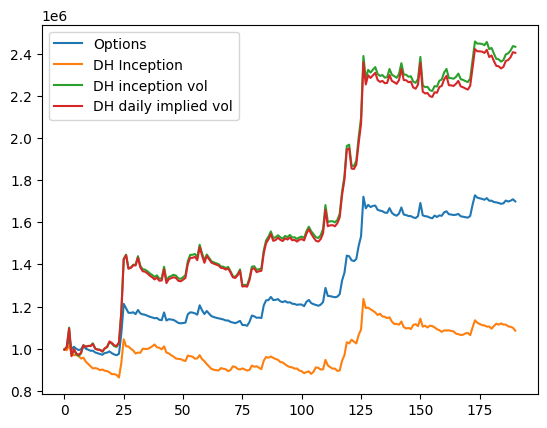

In [4]:
"Plot of wealth using diffrent strategies"
n_w = wealth
plt.plot(n_w.Wealth,label = 'Options')
plt.plot(n_w.Wealth_DHI,label = 'DH Inception')
plt.plot(n_w.Wealth_DHIV,label = 'DH inception vol' )
plt.plot(n_w.Wealth_DHMV,label = 'DH daily implied vol')
plt.legend()

In [5]:
'add savingpath to save pnl and wealth excell sheet to a destination path default path is AAPL "Options/Temp"'
option_request(callput='p',buysell='buy',symbol='SP',maturity=12,mn_dt='delta',strike=15,bot=1,close=12,
               sizing='notional',value=1,dh='on',percent=1,)

200
data written to c:\Users\shyam\Dp Lrn\Options\AAPL Options\scripts\..\Temp\delta_15_p_SP_12_notional.xlsx


In [6]:
""" 
Generating Data of a option not available in DB, The Generated Data will not be saved to DB
To save to DB add the required field to 'data.json' and run 'generate_data()' from gen_data.py or set backfill = True in data_gen.gen_data() function below """
data_gen = de(interpolator='linear',symbool='SP',callput='c')
exp_12 = data_gen.gen_data(moneyness=120, bydelta=False,callput = 'c',bot =1,hold=12,symbool='SP',time_to_expiry=12)#,start_date=20130430,end_date=20140430)

In [7]:
exp_12['df_options']

,Ticker,TradeDate,CallPut,Volume,Delta,Gamma,Vega,Theta,Rho,AdjStrike,...,AdjSpot,AdjExpiry,days_to_expiry,Month_To_Expiry,px,risk_free_rate,Moneyness,ImpliedVolatility,Flag,TradeStart
0,AAPL,20100121,c,893.0,0.369564,0.143446,0.028047,-0.001378,0.021900,8.928571,...,7.431071,20110121,365,12,0.556250,0.002996,120.150000,0.354070,0,20100121
1,AAPL,20100218,c,55.0,0.314594,0.153266,0.024725,-0.001238,0.017350,8.928571,...,7.247500,20110121,337,11,0.400893,0.003444,123.200000,0.332641,0,20100121
2,AAPL,20100318,c,173.0,0.413791,0.169106,0.028760,-0.001480,0.023117,8.928571,...,8.023214,20110121,309,10,0.589286,0.003720,111.280000,0.312082,0,20100121
3,AAPL,20100422,c,1935.0,0.646680,0.137582,0.030646,-0.001880,0.035884,8.928571,...,9.516786,20110121,274,9,1.374107,0.003660,93.820000,0.327619,0,20100121
4,AAPL,20100520,c,1969.0,0.524346,0.124082,0.027759,-0.002623,0.022564,8.928571,...,8.491429,20110121,246,8,1.104464,0.002762,105.150000,0.460352,0,20100121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2397,AAPL,20251016,c,0.0,0.344327,NaN,0.911036,-0.039980,0.724749,295.000000,...,247.450000,20261016,365,12,12.728820,0.040936,119.220000,0.255221,1,20251016
2398,AAPL,20251120,c,0.0,0.445273,0.005693,1.000456,-0.051322,0.891089,295.000000,...,266.250000,20261016,330,11,19.994216,0.036149,110.798122,0.274174,1,20251016
2399,AAPL,20251218,c,0.0,0.455727,0.006346,0.981644,-0.050969,0.869688,295.000000,...,272.190000,20261016,302,10,18.933122,0.034573,108.380176,0.252346,1,20251016
2400,AAPL,20251120,c,0.0,0.341366,0.000223,0.977061,-0.043977,0.768459,320.000000,...,266.250000,20261120,365,12,14.042874,0.039640,120.190000,0.266213,1,20251120


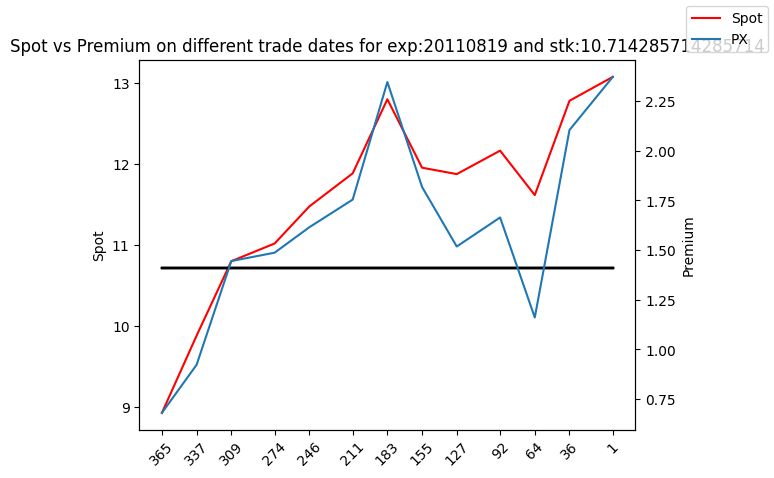

In [8]:
data_gen.plot_px_sp(data_gen.data.AdjExpiry.iloc[100],data_gen.data.AdjStrike.iloc[100])

In [9]:
df = extract_start_data('delta_5_c_SP_12')

In [10]:
df[df.Delta==df.Delta.max()]

,Ticker,TradeDate,CallPut,Volume,Delta,Gamma,Vega,Theta,Rho,AdjStrike,Symbol,AdjSpot,AdjExpiry,days_to_expiry,Month_To_Expiry,px,risk_free_rate,Moneyness,ImpliedVolatility,Flag
5,AAPL,20100617,c,0.0,0.160151,0.075426,0.023639,-0.001078,0.01319,14.285714,SP,9.709643,20110617,365,12,0.236025,0.0005,147.129143,0.332433,1


In [11]:
df = data_gen.get_params_by_trade_date(20100617,'c',12,"SP")
df.shape

(840, 8)

In [12]:
df[(df.ExpiryDate==20110617)&(df.Delta<=.2)]

,TradeDate,ExpiryDate,SP,Stk,px,IV,Delta,Flag
778,20100617,20110617,9.709643,13.928571,0.309715,0.34717197867153843,0.193713,1
779,20100617,20110617,9.709643,14.285714,0.236025,0.33243297239203695,0.160151,1


In [13]:
"Generating PNL use the below function"
opt_pnl = gen_options_pnl(delta=15,bydelta=True,time_to_expiry=12,callput='p',bot=1,hold=12,interpolator='linear',symbool='SP',dh='on')

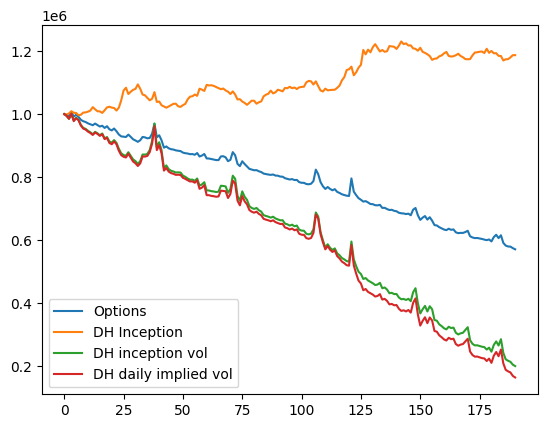

In [14]:
"Plot of wealth using diffrent strategies"
n_df,n_w = wealth_computation(opt_pnl,sizing ='notional',hold=12,dh='on')
p_df,n_p = wealth_computation(opt_pnl,sizing='premium',pct=1,hold=12,dh='on')
c_df,n_c = wealth_computation(opt_pnl,sizing='contracts',hold=12,dh='on')
plt.plot(n_w.Wealth,label = 'Options')
plt.plot(n_w.Wealth_DHI,label = 'DH Inception')
plt.plot(n_w.Wealth_DHIV,label = 'DH inception vol' )
plt.plot(n_w.Wealth_DHMV,label = 'DH daily implied vol')
plt.legend()

#### To acess the Option PNL function from Window Power Shell use the following commands
1.Activate the Options env : conda activate Options  
2.navigate to AAPL Options Directory  
3 use :  python -m scripts.application --cp c --buysell buy --symbol SP --exp 6 --mn_dt delta --stk 20 --bot 1 --hold 6 --path "C:\Users\shyam\Dp Lrn\Options\AAPL Options"  
following are the flags :   
--cp ['c','p']  
--buysell ['buy','sell']  
--symbol ['SP','EV']  
--exp [1,3,6,12]  
--mn_dt ['mn','delta']  
--stk [80,90,100] for put moneyness, [100,110,120] for call moneyness, [5,10,15,20,25,30] for delta  
--hold 1<=--hold<=exp  
--path : path to saving directory   